Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/malakmekyassi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##### Data Acquisition & Standardizing Labels:

Given we're working on two different datasets, we need to bring them together into a "Common Data Format", which prevents us from writing redundant code later. We'll create a unified `text` and `label` column for both

Dataset 1:

In [2]:
df_true = pd.read_csv('data/News _dataset/True.csv')
df_fake = pd.read_csv('data/News _dataset/Fake.csv')
df_true['label'] = 1
df_fake['label'] = 0
data1 = pd.concat([df_true, df_fake]).sample(frac=0.1, random_state=RANDOM_STATE)
text_col = "text" if "text" in data1.columns else data1.columns[0]
data1 = data1[[text_col, "label"]].dropna().rename(columns={text_col: "text"})
data1.describe()

,label
count,4490.000000
mean,0.484633
std,0.499819
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Dataset 2:

In [3]:
data2 = pd.read_csv('data/df_file.csv')
data2 = data2.rename(columns={'Text': 'text', 'Label': 'label'})
data2 = data2[['text', 'label']].dropna()
data2.describe()

,label
count,2225.000000
mean,2.027416
std,1.438694
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


### Preprocessing

The following function removes the noise (numbers, punctuation, stopwords) that doesn't contribute to the core meaning of the sentence

In [4]:
def backbone_cleaner(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

In [5]:
data1['cleaned_base'] = data1['text'].apply(backbone_cleaner)
data2['cleaned_base'] = data2['text'].apply(backbone_cleaner)

In [6]:
data1.head()

,text,label,cleaned_base
799,"Donald Trump s White House is in chaos, and th...",0,donald trump white house chaos trying cover ru...
6500,Now that Donald Trump is the presumptive GOP n...,0,donald trump presumptive gop nominee time reme...
3590,Mike Pence is a huge homophobe. He supports ex...,0,mike pence huge homophobe supports exgay conve...
1377,SAN FRANCISCO (Reuters) - California Attorney ...,1,san francisco reuters california attorney gene...
11059,Twisted reasoning is all that comes from Pelos...,0,twisted reasoning comes pelosi days especially...


In [7]:
data2.head()

,text,label,cleaned_base
0,Budget to set scene for election\n \n Gordon B...,0,budget set scene election gordon brown seek pu...
1,Army chiefs in regiments decision\n \n Militar...,0,army chiefs regiments decision military chiefs...
2,Howard denies split over ID cards\n \n Michael...,0,howard denies split id cards michael howard de...
3,Observers to monitor UK election\n \n Minister...,0,observers monitor uk election ministers invite...
4,Kilroy names election seat target\n \n Ex-chat...,0,kilroy names election seat target exchat show ...


#### Implementing the Stemming Variants

Here we move to the part in which we compare Control (No Stemming) against three major algorithms: Porter, Snowball, Lancaster.

We should note the "Aggression Spectrum": Porter(Mild) < Snowball (Balanced) < Lancaster (Extreme)

In [8]:
p_stemmer = PorterStemmer()
s_stemmer = SnowballStemmer('english')
l_stemmer = LancasterStemmer()

In [9]:
def apply_stemming(text, stemmer):
    words = text.split()
    if stemmer == 'porter':
        return " ".join([p_stemmer.stem(w) for w in words])
    elif stemmer == 'snowball':
        return " ".join([s_stemmer.stem(w) for w in words])
    elif stemmer == 'lancaster':
        return " ".join([l_stemmer.stem(w) for w in words])
    return text

In [10]:
stemmer = ['none', 'porter', 'snowball', 'lancaster']
data1_variants = {m: data1['cleaned_base'].apply(lambda x: apply_stemming(x, m)) for m in stemmer}
data2_variants = {m: data2['cleaned_base'].apply(lambda x: apply_stemming(x, m)) for m in stemmer}

In [11]:
data1_variants['porter'].head()

799      donald trump white hous chao tri cover russia ...
6500     donald trump presumpt gop nomine time rememb c...
3590     mike penc huge homophob support exgay convers ...
1377     san francisco reuter california attorney gener...
11059    twist reason come pelosi day especi promin dem...
Name: cleaned_base, dtype: str

### Benchmarking with Random Forest

We use TF-IDF vectorization to convert text into numbers. We then train a RF (100 trees) on each version. We track `Vocab_Size` to see how much each stemmer "shrinks" the data

In [12]:
def run_benchmarks(variants_dict, labels):
    results = []
    tfidf = TfidfVectorizer(max_features=5000)
    for method, texts in variants_dict.items():
        X = tfidf.fit_transform(texts)
        y = labels
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
        rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
        rf.fit(X_train, y_train)
        #Evaluate
        preds = rf.predict(X_test)
        results.append({
            'Stemmer': method.capitalize(),
            'Accuracy': accuracy_score(y_test, preds),
            'F1 Score': f1_score(y_test, preds, average='weighted'),
            'Vocab Size': len(tfidf.vocabulary_)
        })
    return pd.DataFrame(results)

In [13]:
rest1_df = run_benchmarks(data1_variants, data1['label'])
rest2_df = run_benchmarks(data2_variants, data2['label'])

In [14]:
rest1_df.head()

,Stemmer,Accuracy,F1 Score,Vocab Size
0,None,0.992205,0.992205,5000
1,Porter,0.992205,0.992206,5000
2,Snowball,0.988864,0.988865,5000
3,Lancaster,0.989978,0.989977,5000


In [15]:
rest2_df.head()

,Stemmer,Accuracy,F1 Score,Vocab Size
0,None,0.950562,0.950568,5000
1,Porter,0.961798,0.961719,5000
2,Snowball,0.955056,0.954951,5000
3,Lancaster,0.948315,0.948115,5000


### Visualization:

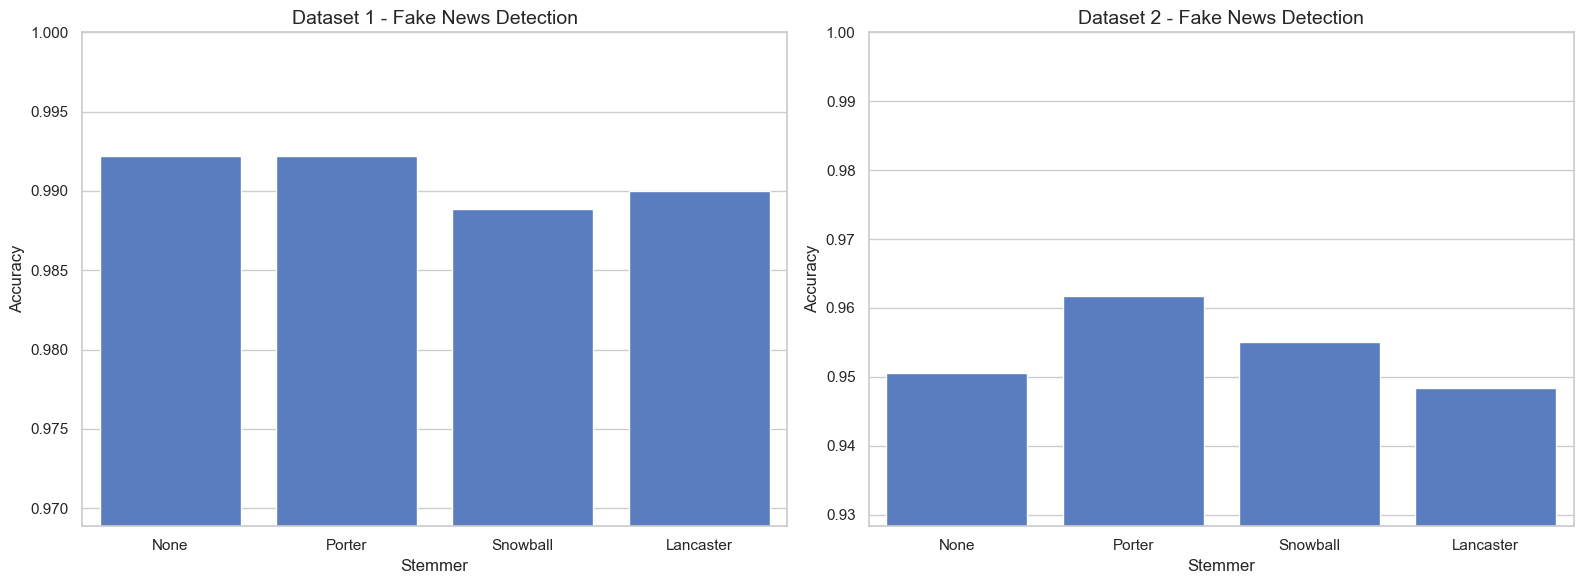

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Stemmer', y='Accuracy', data=rest1_df, ax=ax[0])
ax[0].set_title('Dataset 1 - Fake News Detection', fontsize=14)
ax[0].set_ylim(min(rest1_df['Accuracy']) - 0.02, 1.0)

sns.barplot(x='Stemmer', y='Accuracy', data=rest2_df, ax=ax[1])
ax[1].set_title('Dataset 2 - Fake News Detection', fontsize=14)
ax[1].set_ylim(min(rest2_df['Accuracy']) - 0.02, 1.0)
plt.tight_layout()
plt.show()

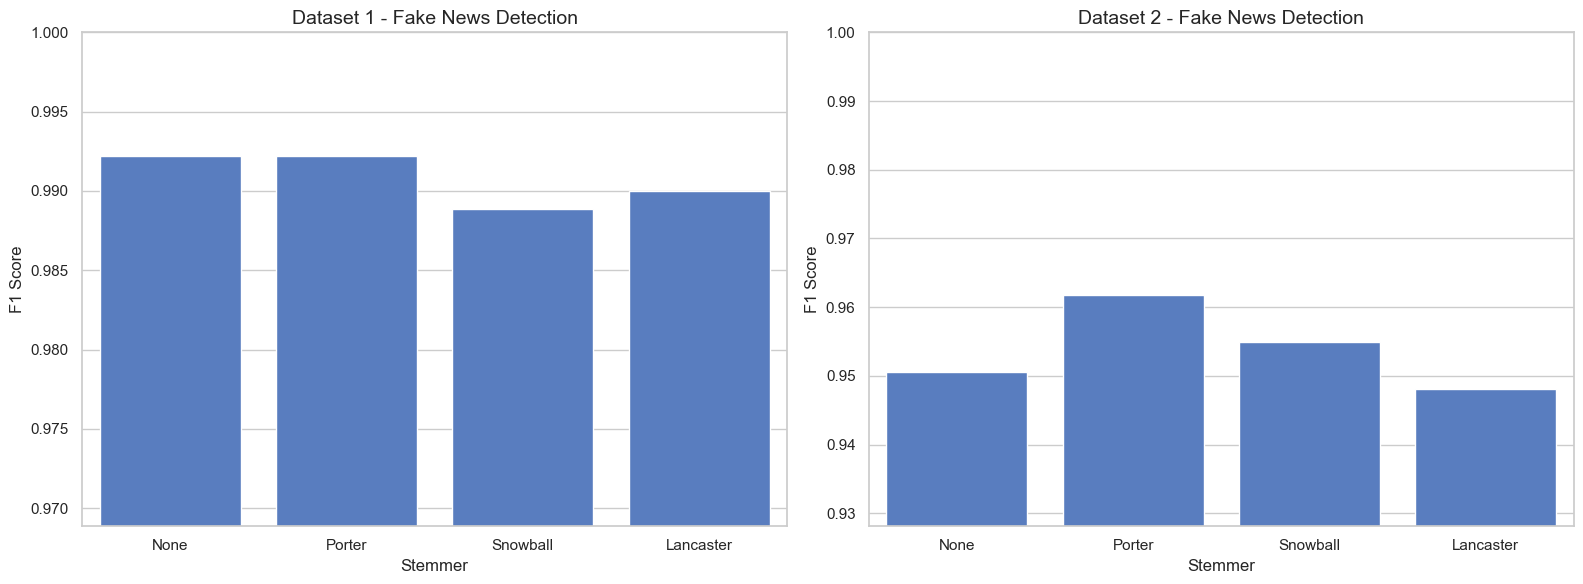

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Stemmer', y='F1 Score', data=rest1_df, ax=ax[0])
ax[0].set_title('Dataset 1 - Fake News Detection', fontsize=14)
ax[0].set_ylim(min(rest1_df['F1 Score']) - 0.02, 1.0)

sns.barplot(x='Stemmer', y='F1 Score', data=rest2_df, ax=ax[1])
ax[1].set_title('Dataset 2 - Fake News Detection', fontsize=14)
ax[1].set_ylim(min(rest2_df['F1 Score']) - 0.02, 1.0)
plt.tight_layout()
plt.show()